In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


In [2]:
data = pd.read_csv('PlayTennis.csv')

In [3]:
data.head(2)

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No


In [4]:
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

In [5]:
outlook_encoder = OrdinalEncoder()
data['Outlook']  =outlook_encoder.fit_transform(data[['Outlook']])


In [6]:
le = LabelEncoder()
for col in data.columns:
    data[col] =  le.fit_transform(data[col])

In [7]:
play_encoder = OrdinalEncoder()
data['play'] = play_encoder.fit_transform(data[['Play Tennis']])

In [8]:
x = data.drop(['Play Tennis'], axis = 1)
y = data['Play Tennis']

In [9]:
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(x,y)
y_pred_gini  = clf_gini.predict(x)


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
print("accuracy_score", accuracy_score(y, y_pred_gini))
print("", classification_report(y, y_pred_gini))
print("", confusion_matrix(y, y_pred_gini))

accuracy_score 1.0
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

 [[5 0]
 [0 9]]


[Text(0.5, 0.75, 'play <= 0.5\ngini = 0.459\nsamples = 14\nvalue = [5, 9]\nclass = y[1]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = y[0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]\nclass = y[1]'),
 Text(0.625, 0.5, '  False')]

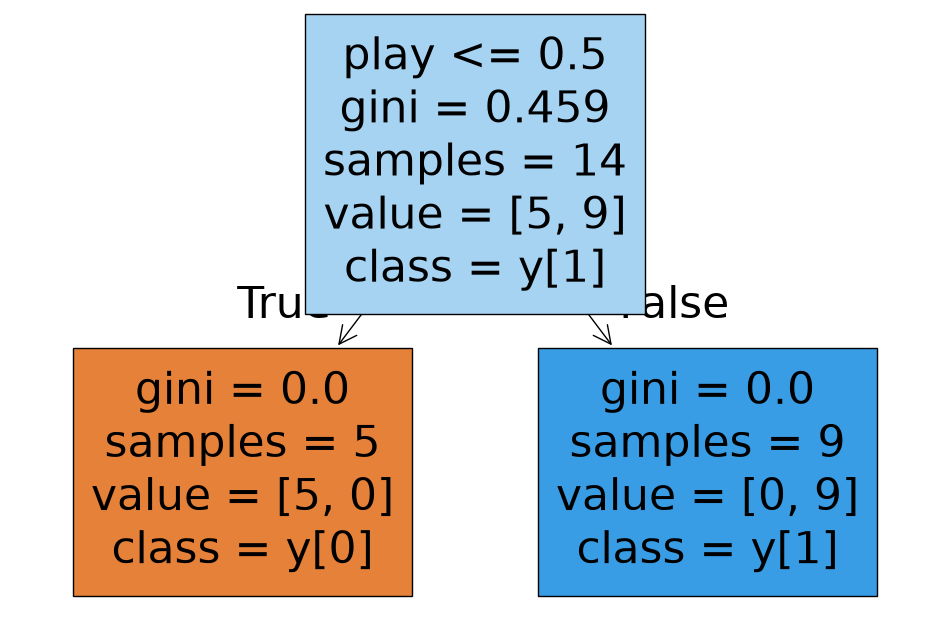

In [12]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_gini, filled=True, feature_names=x.columns, class_names=True)